# IMPORTATION GLOBAL

In [3]:
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Palette sobre et impactante ──────────────────────────────
PALETTE_MAIN   = "#2C3E50"   # bleu ardoise foncé
PALETTE_ACCENT = "#E74C3C"   # rouge alerte
PALETTE_OK     = "#27AE60"   # vert normal
PALETTE_WARN   = "#F39C12"   # orange warning
PALETTE_SEQ    = "YlOrRd"    # séquentielle pour heatmaps
PALETTE_DIV    = "coolwarm"  # divergente pour comparaisons

COLOR_CYCLE = [PALETTE_MAIN, PALETTE_ACCENT, PALETTE_OK, PALETTE_WARN, "#8E44AD", "#2980B9"]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#CCCCCC",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "figure.dpi":       130,
})

print("✅ Configuration chargée")

✅ Configuration chargée


# Chargement des données

In [4]:
from src.data_loader import load_expenses_from_sql
from src.scorer import score_anomalies, get_anomaly_summary, get_top_anomalies

In [5]:
# Chargement
df_raw    = load_expenses_from_sql(Path("../data/local_genuka_table_expenses.sql"))
df_scored = score_anomalies(df_raw)
summary   = get_anomaly_summary(df_scored)

2026-02-28 04:40:38 | INFO     | src.data_loader | 📂 Chargement du fichier SQL : ..\data\local_genuka_table_expenses.sql
2026-02-28 04:40:38 | INFO     | src.data_loader | 📄 Fichier lu : 2,855,454 caractères
2026-02-28 04:40:38 | INFO     | src.data_loader | ✅ 23 colonnes extraites : ['id', 'company_id', 'user_id', 'shop_id', 'supplier_id', 'reference', 'status', 'currency', 'amount', 'source', 'due_date', 'paid_at', 'items', 'shipping', 'billing', 'metadata', 'created_at', 'updated_at', 'deleted_at', 'expense_type', 'credit_code', 'debit_code', 'state']
2026-02-28 04:40:39 | INFO     | src.data_loader | 🔍 58 bloc(s) INSERT trouvé(s), parsing en cours...
2026-02-28 04:41:20 | INFO     | src.data_loader | ✅ 5028 lignes parsées avec succès.
2026-02-28 04:41:20 | INFO     | src.data_loader | 📊 DataFrame créé : 5028 lignes × 23 colonnes
2026-02-28 04:41:21 | INFO     | src.data_loader | ✅ Chargement terminé avec succès.
2026-02-28 04:41:21 | INFO     | src.data_loader | 
id                

In [6]:
# Séparation anomalies / normales
df_anomalies = df_scored[df_scored["is_anomaly"] == 1].copy()
df_normal    = df_scored[df_scored["is_anomaly"] == 0].copy()

In [7]:
print(f"✅ {len(df_scored):,} transactions chargées")
print(f"   → {len(df_anomalies)} anomalies ({summary['anomaly_rate_pct']}%)")
print(f"   → {len(df_normal):,} transactions normales")

✅ 4,772 transactions chargées
   → 53 anomalies (1.11%)
   → 4,719 transactions normales


In [8]:
df_scored.head(3)

,id,company_id,user_id,shop_id,supplier_id,reference,amount,currency,source,expense_type,...,anomaly_lof,anomaly_dbscan,anomaly_rules,is_fraud_pattern,is_anomaly,fraud_splitting,fraud_duplicate,fraud_ghost_supplier,fraud_inflation,rules_triggered
0,01jj6rnsg0r4jgff4zmxwak9q9,01jdcazzn2y339b471kp39x7n0,01jhavkj02vhq0xtbjqpxjemry,01jdy1qcsfz4zkgb3g9k4qwr1k,NaN,#BILL_1016,200.0,XAF,AUTRE/OTHER,personnel,...,0,1,0,0,0,0.0,0.0,0.0,0.0,
1,01jze6149pp5bzkv7k3ga1khb7,01jphx67exdxsh91bjt8ea745d,01jphx6c1vpgkdpkxa2nh6mnxp,01jphx6bm80w4qx9cne40zjgvd,NaN,#BILL_1018,900000.0,XAF,AUTRE/OTHER,raw_materials,...,0,1,0,0,0,0.0,0.0,0.0,0.0,Montant en dehors du IQR par utilisateur | Mon...
2,01ht3ff7d58bfqgbwbe706j51g,01hjpwjzgwr3y0d62wywg6z1pp,01hjpwjzw1g10wq5zt0tjbw08s,01hjpwjzh2d2k9td9r45qd8jm1,01ht3fpk37xw5g8dpz9bnk913w,#BILL_1003,10000.0,XAF,WHATSAPP,supplier,...,0,1,0,0,0,0.0,0.0,0.0,0.0,Transaction hors heures de bureau


# Vue d'ensemble chiffree

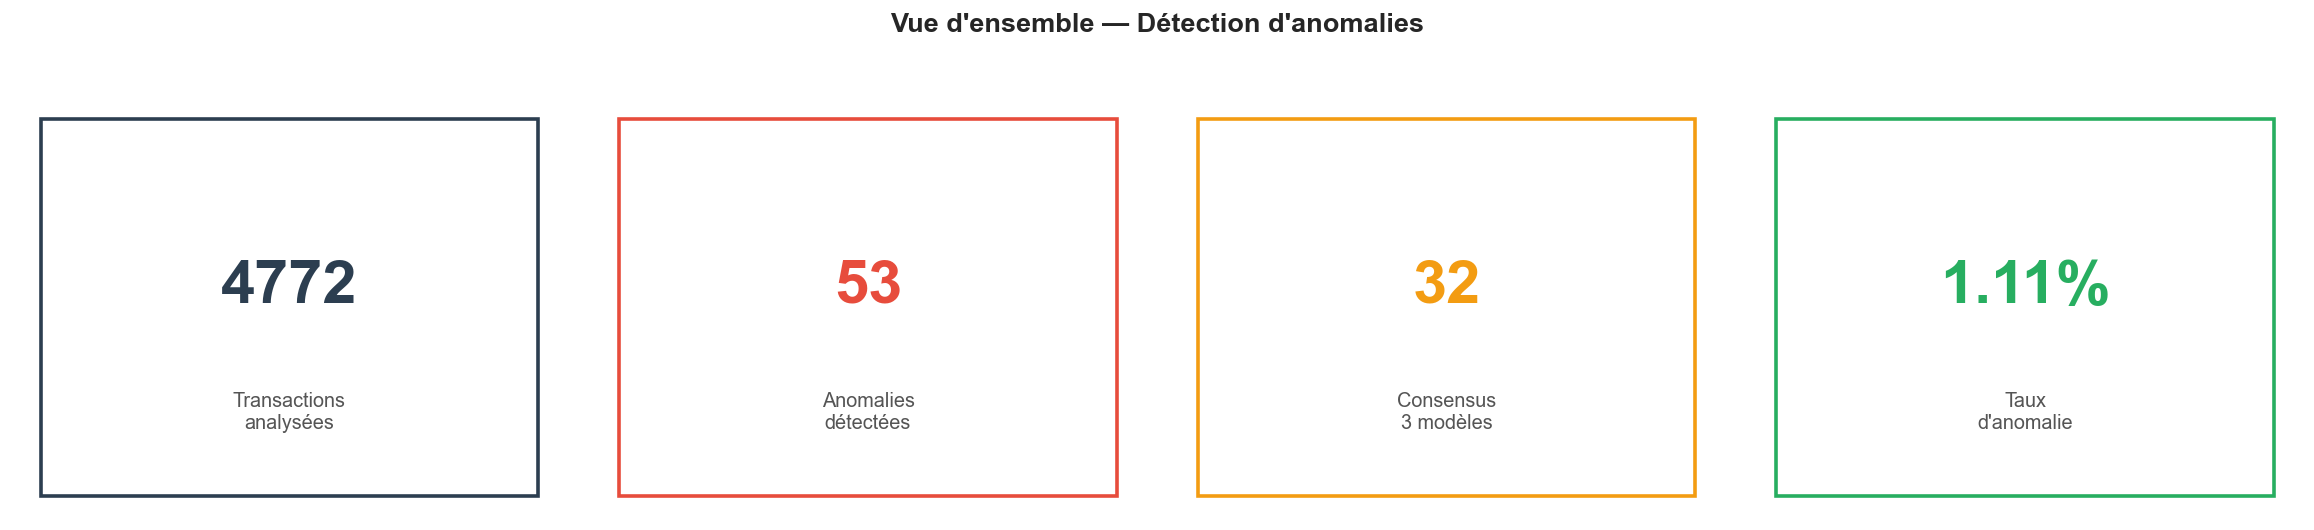

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Vue d'ensemble — Détection d'anomalies", fontsize=15, fontweight="bold", y=1.02)

metrics = [
    ("Transactions\nanalysées",  summary["total_transactions"],  PALETTE_MAIN),
    ("Anomalies\ndétectées",     summary["total_anomalies"],      PALETTE_ACCENT),
    ("Consensus\n3 modèles",     summary["consensus_3_models"],   PALETTE_WARN),
    ("Taux\nd'anomalie",         f"{summary['anomaly_rate_pct']}%", PALETTE_OK),
]

for ax, (label, value, color) in zip(axes, metrics):
    ax.text(0.5, 0.55, str(value), ha="center", va="center",
            fontsize=34, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center",
            fontsize=11, color="#555555", transform=ax.transAxes)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.90, 0.90,
                                fill=False, edgecolor=color,
                                linewidth=2, transform=ax.transAxes))

plt.tight_layout()
plt.show()

# Distribution des scores finaux

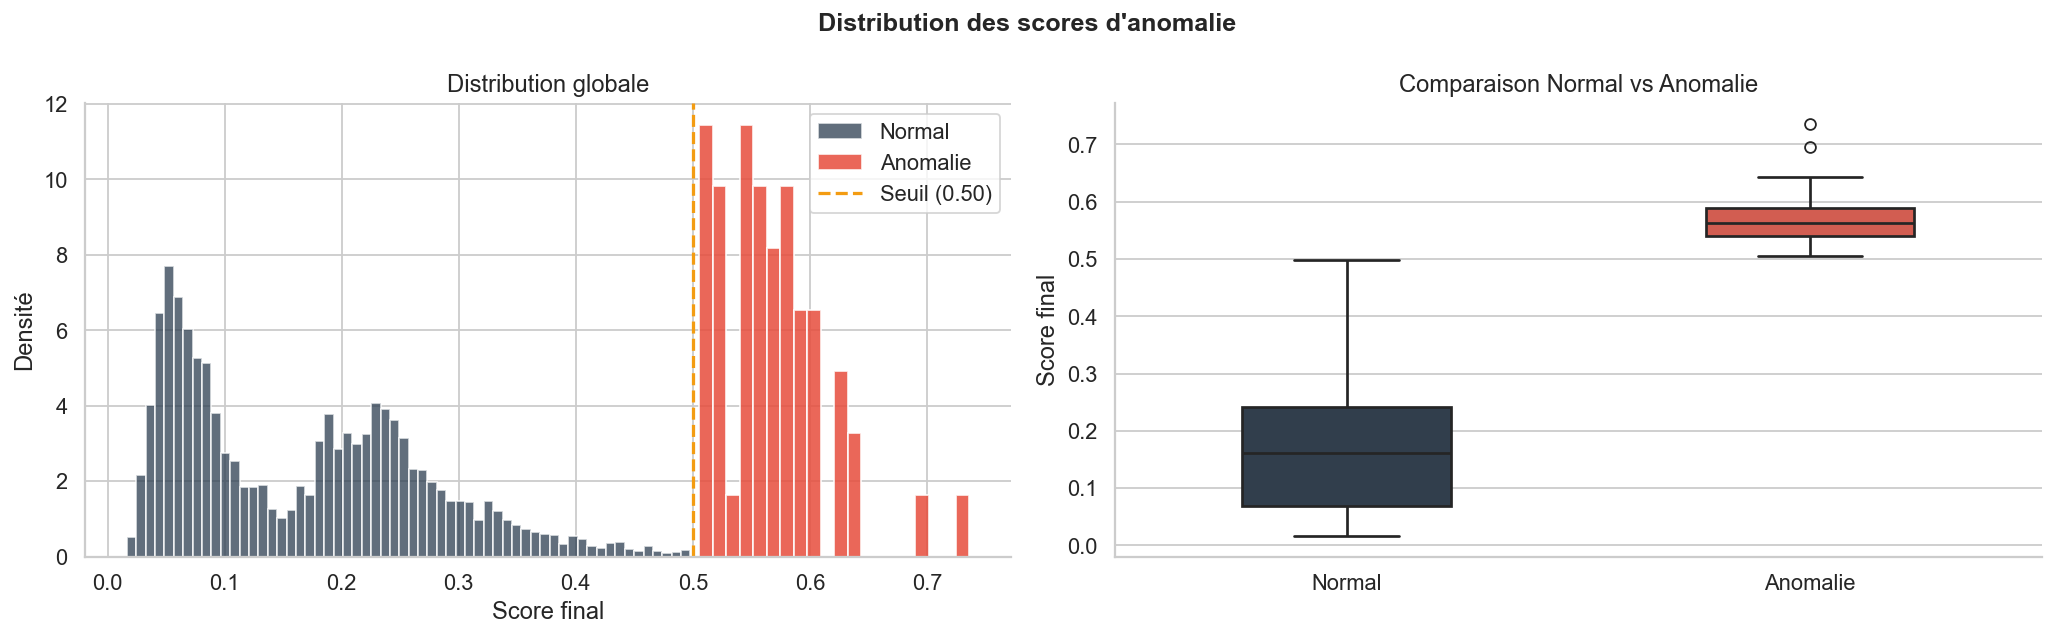

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribution des scores d'anomalie", fontsize=14, fontweight="bold")

# Histogramme global
ax = axes[0]
ax.hist(df_normal["score_final"],    bins=60, color=PALETTE_MAIN,   alpha=0.75, label="Normal",   density=True)
ax.hist(df_anomalies["score_final"], bins=20, color=PALETTE_ACCENT, alpha=0.85, label="Anomalie", density=True)
ax.axvline(0.50, color=PALETTE_WARN, linestyle="--", linewidth=1.8, label="Seuil (0.50)")
ax.set_xlabel("Score final")
ax.set_ylabel("Densité")
ax.set_title("Distribution globale")
ax.legend()

# Boxplot par catégorie
ax = axes[1]
plot_data = pd.DataFrame({
    "score": pd.concat([df_normal["score_final"], df_anomalies["score_final"]]),
    "type":  ["Normal"] * len(df_normal) + ["Anomalie"] * len(df_anomalies),
})
sns.boxplot(data=plot_data, x="type", y="score", palette=[PALETTE_MAIN, PALETTE_ACCENT],
            width=0.45, linewidth=1.5, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Score final")
ax.set_title("Comparaison Normal vs Anomalie")

plt.tight_layout()
plt.show()

# Comparaison des 5 modeles

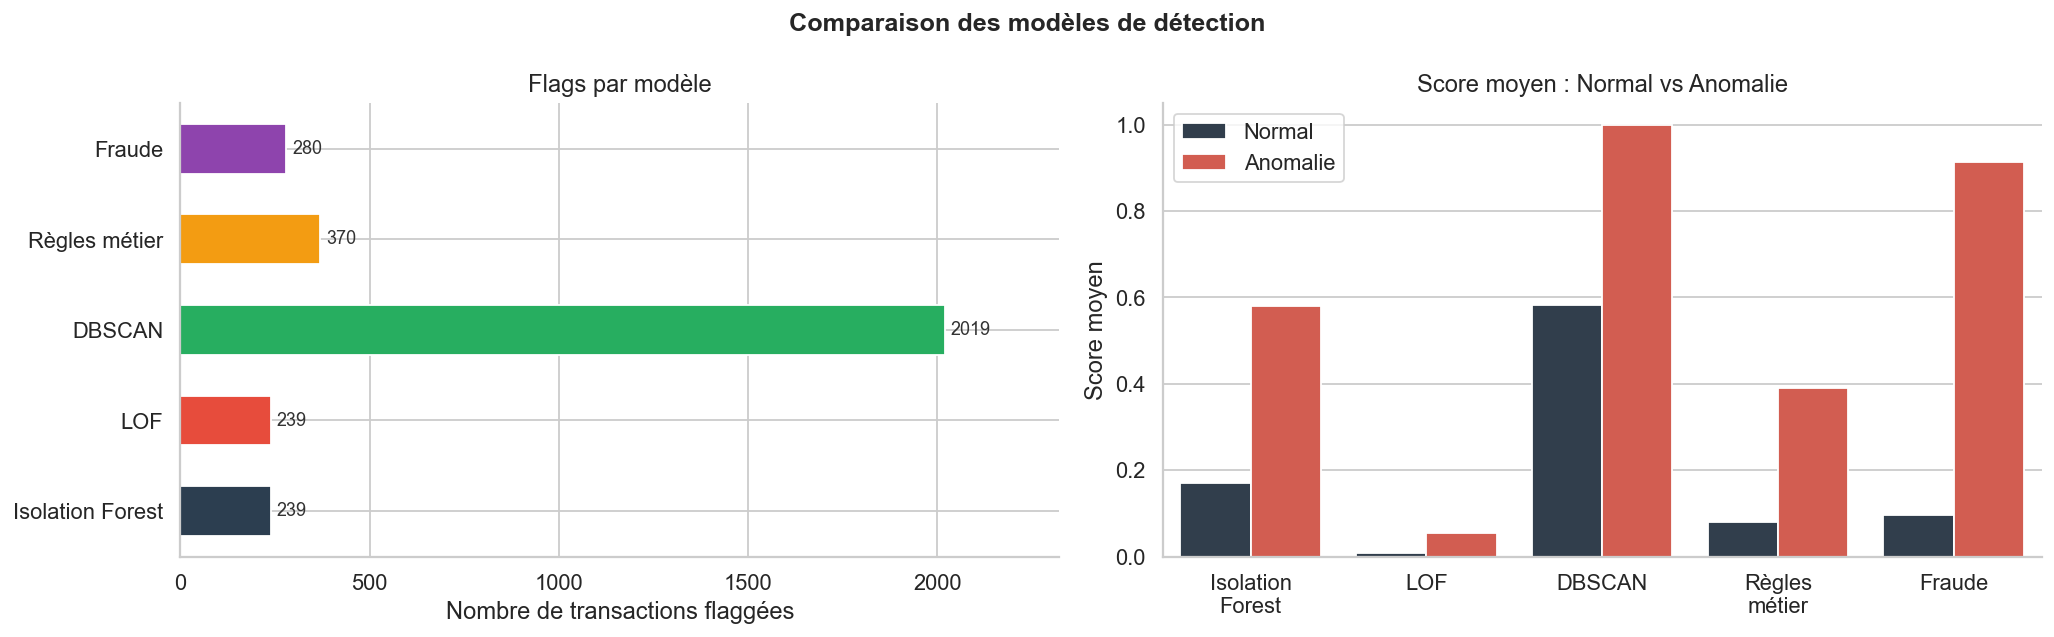

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Comparaison des modèles de détection", fontsize=14, fontweight="bold")

score_cols = {
    "Isolation\nForest": "score_if",
    "LOF":               "score_lof",
    "DBSCAN":            "score_dbscan",
    "Règles\nmétier":    "score_rules",
    "Fraude":            "score_fraud",
}

# Nombre de flags par modèle
ax = axes[0]
flag_cols = {
    "Isolation Forest": "anomaly_if",
    "LOF":              "anomaly_lof",
    "DBSCAN":           "anomaly_dbscan",
    "Règles métier":    "anomaly_rules",
    "Fraude":           "is_fraud_pattern",
}
counts = {label: df_scored[col].sum() for label, col in flag_cols.items()}
bars = ax.barh(list(counts.keys()), list(counts.values()),
               color=COLOR_CYCLE[:5], edgecolor="white", height=0.55)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10, color="#333333")
ax.set_xlabel("Nombre de transactions flaggées")
ax.set_title("Flags par modèle")
ax.set_xlim(0, max(counts.values()) * 1.15)

# Scores moyens par modèle (anomalies vs normales)
ax = axes[1]
rows = []
for label, col in score_cols.items():
    if col in df_scored.columns:
        rows.append({"Modèle": label, "Type": "Normal",   "Score": df_normal[col].mean()})
        rows.append({"Modèle": label, "Type": "Anomalie", "Score": df_anomalies[col].mean()})

df_model_scores = pd.DataFrame(rows)
sns.barplot(data=df_model_scores, x="Modèle", y="Score", hue="Type",
            palette=[PALETTE_MAIN, PALETTE_ACCENT], edgecolor="white", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Score moyen")
ax.set_title("Score moyen : Normal vs Anomalie")
ax.legend(title="")

plt.tight_layout()
plt.show()

# Heatmap des regles declenchees

ValueError: Axis limits cannot be NaN or Inf

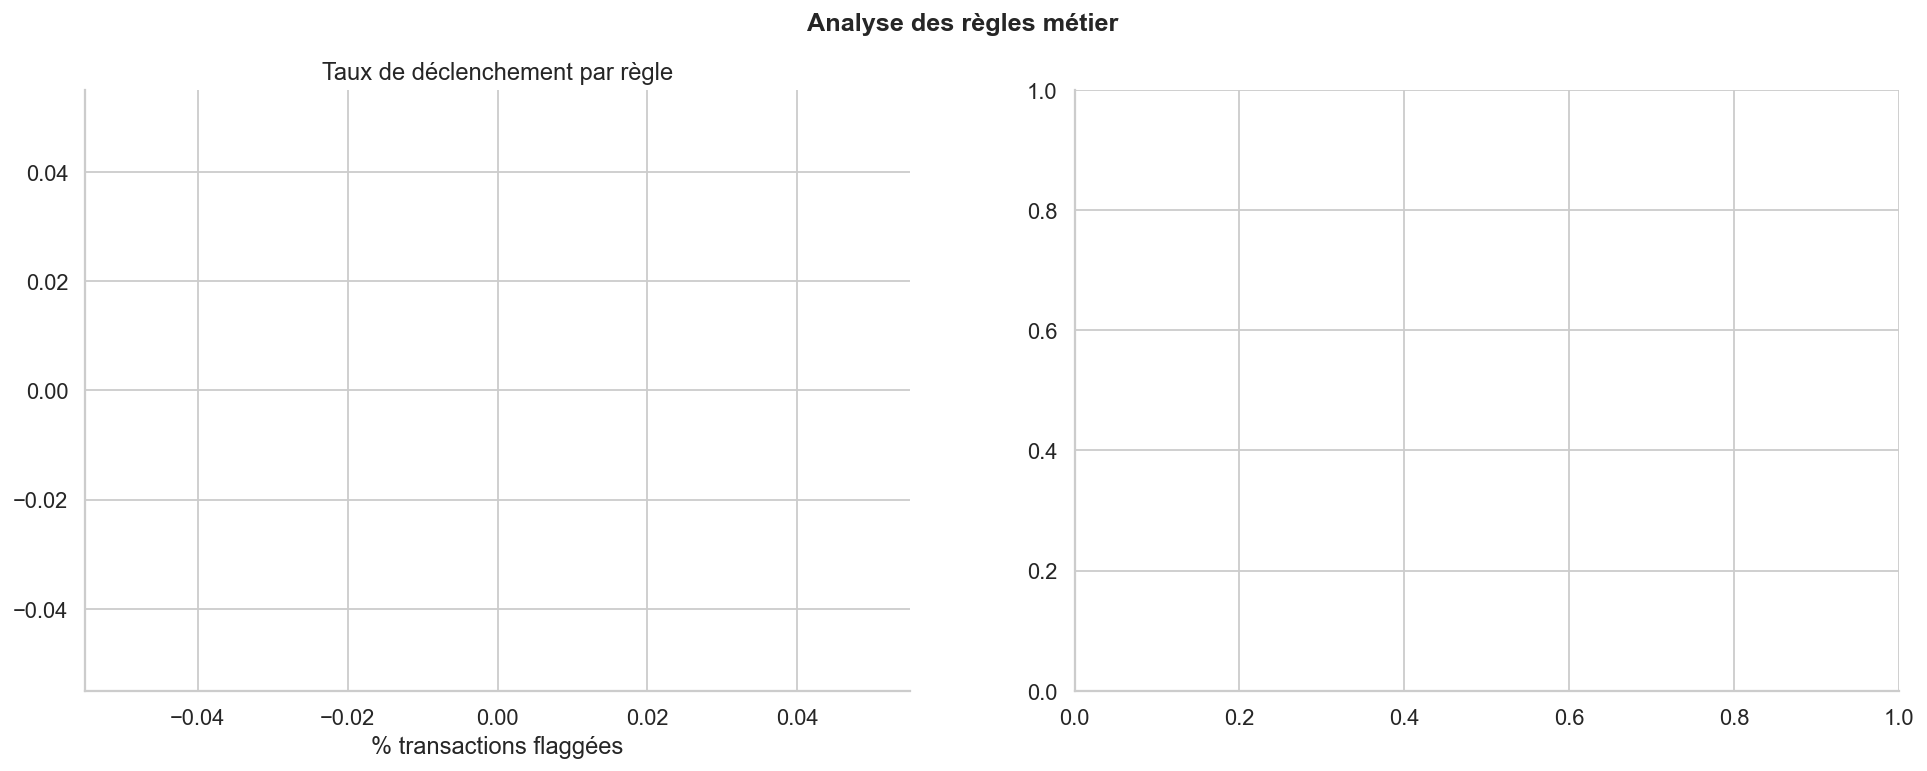

In [12]:
rule_cols = [c for c in df_scored.columns if c.startswith("rule_")]

rule_labels = {
    "rule_high_amount_global":          "Montant élevé (global)",
    "rule_high_amount_vs_user":         "Montant élevé (vs user)",
    "rule_weekend":                     "Week-end",
    "rule_outside_hours":               "Hors horaires",
    "rule_rare_supplier":               "Fournisseur rare",
    "rule_rolling_spike":               "Spike montant (7j)",
    "rule_high_daily_freq":             "Fréquence journalière",
    "rule_round_amount":                "Montant rond",
    "rule_unusual_source_for_user":     "Source inhabituelle (user)",
    "rule_unusual_type_for_user":       "Type inhabituel (user)",
    "rule_unusual_hour_for_user":       "Heure inhabituelle (user)",
    "rule_amount_far_from_user_median": "Montant 5x médiane (user)",
}

# Taux de déclenchement par règle
available_rules = [c for c in rule_cols if c in df_scored.columns]
rule_rates = df_scored[available_rules].mean().rename(
    index={c: rule_labels.get(c, c) for c in available_rules}
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Analyse des règles métier", fontsize=14, fontweight="bold")

# Taux de déclenchement global
ax = axes[0]
colors = [PALETTE_ACCENT if v > 0.10 else PALETTE_WARN if v > 0.05 else PALETTE_MAIN
          for v in rule_rates.values]
bars = ax.barh(rule_rates.index, rule_rates.values * 100,
               color=colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, rule_rates.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% transactions flaggées")
ax.set_title("Taux de déclenchement par règle")
ax.set_xlim(0, rule_rates.max() * 100 * 1.2)

# Heatmap règles × top anomalies
ax = axes[1]
top_anomalies = get_top_anomalies(df_scored, n=20)
heatmap_data = top_anomalies[available_rules].rename(
    columns={c: rule_labels.get(c, c) for c in available_rules}
).T

sns.heatmap(heatmap_data, ax=ax, cmap=PALETTE_SEQ, linewidths=0.4,
            linecolor="#EEEEEE", cbar_kws={"label": "Déclenché"},
            xticklabels=[f"#{i+1}" for i in range(len(top_anomalies))],
            yticklabels=True)
ax.set_xlabel("Top 20 anomalies (rang)")
ax.set_title("Règles déclenchées — Top 20 anomalies")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

# Timeline des anomalies

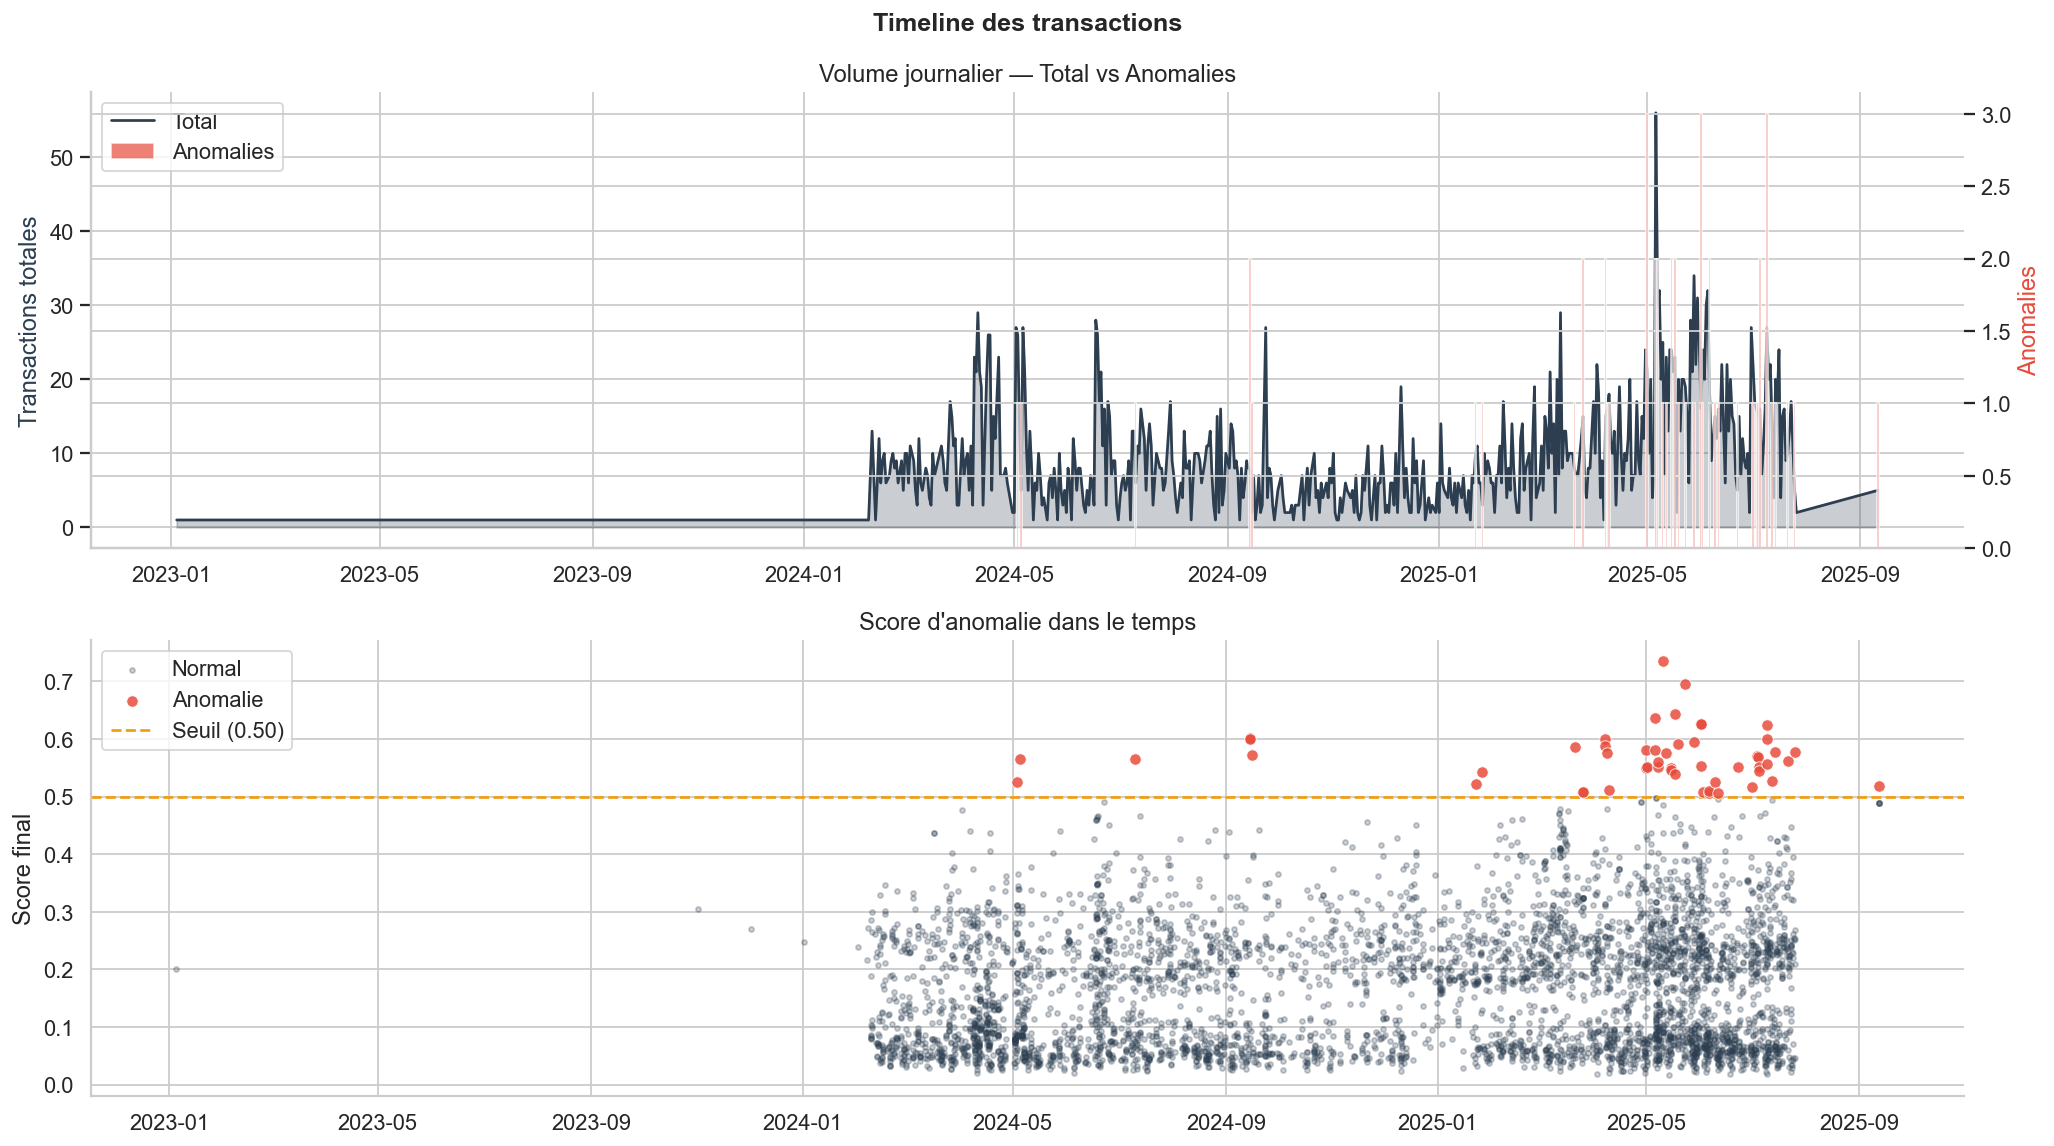

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle("Timeline des transactions", fontsize=14, fontweight="bold")

df_time = df_scored.copy()
df_time["date"] = pd.to_datetime(df_time["created_at"]).dt.date

# Volume journalier
daily_all      = df_time.groupby("date").size().reset_index(name="total")
daily_anomalies = df_time[df_time["is_anomaly"]==1].groupby("date").size().reset_index(name="anomalies")
daily = daily_all.merge(daily_anomalies, on="date", how="left").fillna(0)

ax = axes[0]
ax.fill_between(daily["date"], daily["total"], alpha=0.25, color=PALETTE_MAIN)
ax.plot(daily["date"], daily["total"], color=PALETTE_MAIN, linewidth=1.5, label="Total")
ax2 = ax.twinx()
ax2.bar(daily["date"], daily["anomalies"], color=PALETTE_ACCENT, alpha=0.7, width=0.8, label="Anomalies")
ax.set_ylabel("Transactions totales", color=PALETTE_MAIN)
ax2.set_ylabel("Anomalies", color=PALETTE_ACCENT)
ax.set_title("Volume journalier — Total vs Anomalies")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Score final dans le temps
ax = axes[1]
df_normal_t    = df_time[df_time["is_anomaly"]==0]
df_anomalies_t = df_time[df_time["is_anomaly"]==1]
ax.scatter(df_normal_t["created_at"],    df_normal_t["score_final"],
           color=PALETTE_MAIN,   alpha=0.25, s=8,  label="Normal", zorder=2)
ax.scatter(df_anomalies_t["created_at"], df_anomalies_t["score_final"],
           color=PALETTE_ACCENT, alpha=0.85, s=40, label="Anomalie",
           edgecolors="white", linewidth=0.5, zorder=3)
ax.axhline(0.50, color=PALETTE_WARN, linestyle="--", linewidth=1.5, label="Seuil (0.50)")
ax.set_ylabel("Score final")
ax.set_title("Score d'anomalie dans le temps")
ax.legend()

plt.tight_layout()
plt.show()

# Analyse des patterns de fraudes

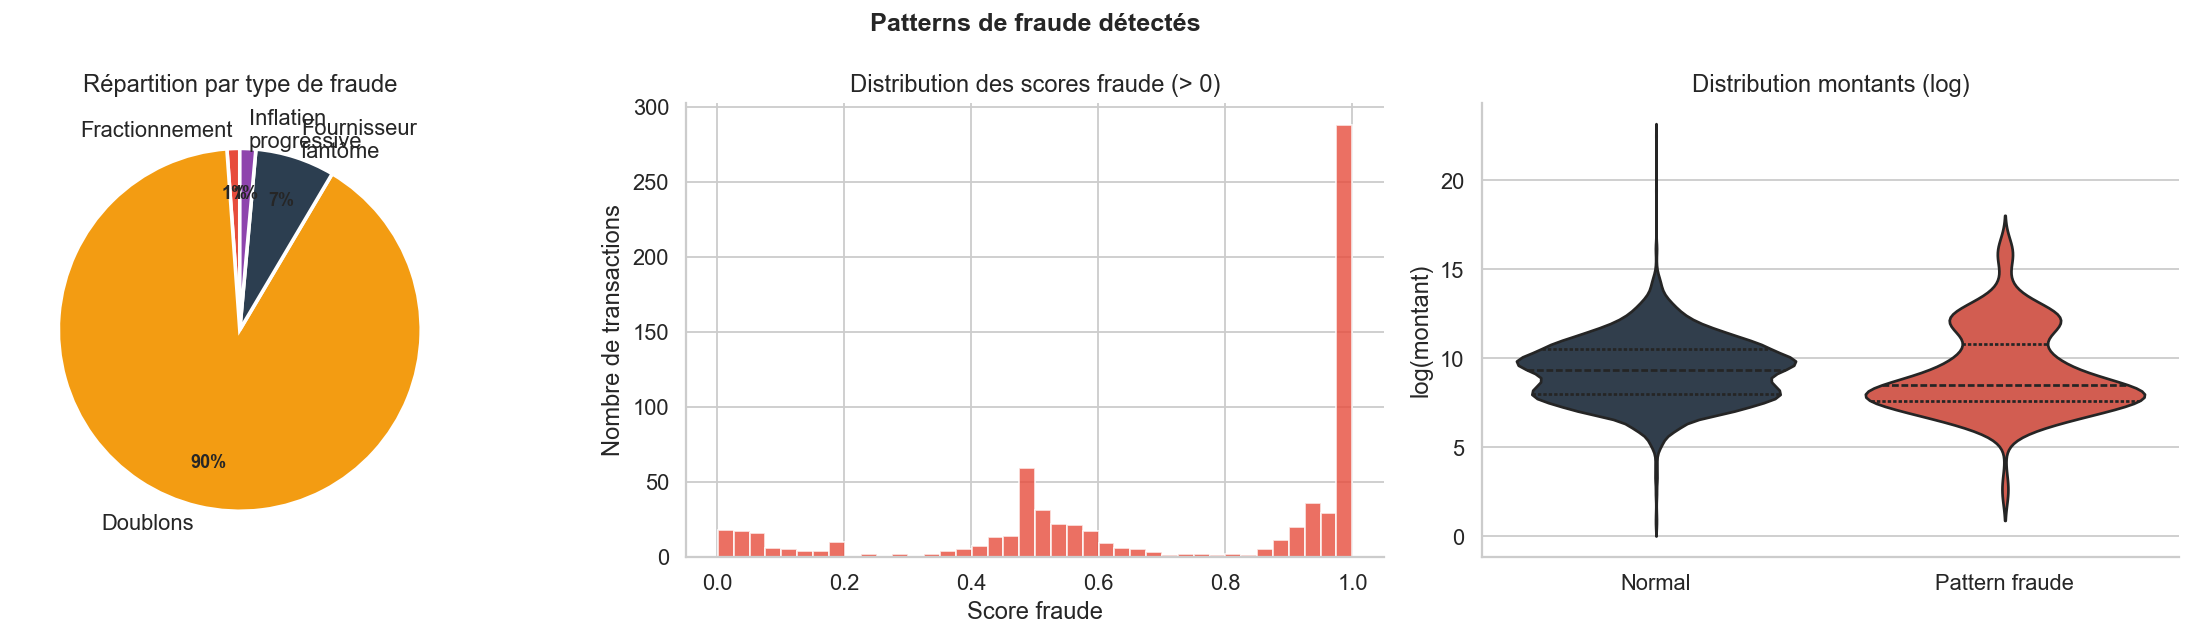

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Patterns de fraude détectés", fontsize=14, fontweight="bold")

# Répartition des types de fraude
ax = axes[0]
fraud_counts = {
    "Fractionnement":       summary["fraud_splitting"],
    "Doublons":             summary["fraud_duplicates"],
    "Fournisseur\nfantôme": summary["fraud_ghost_supplier"],
    "Inflation\nprogressive": summary["fraud_inflation"],
}
wedge_colors = [PALETTE_ACCENT, PALETTE_WARN, PALETTE_MAIN, "#8E44AD"]
non_zero = {k: v for k, v in fraud_counts.items() if v > 0}
if non_zero:
    wedges, texts, autotexts = ax.pie(
        non_zero.values(), labels=non_zero.keys(),
        colors=wedge_colors[:len(non_zero)], autopct="%1.0f%%",
        startangle=90, pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    for t in autotexts:
        t.set_fontsize(10); t.set_fontweight("bold")
ax.set_title("Répartition par type de fraude")

# Distribution score fraude
ax = axes[1]
fraud_scores = df_scored["score_fraud"][df_scored["score_fraud"] > 0]
ax.hist(fraud_scores, bins=40, color=PALETTE_ACCENT, alpha=0.8, edgecolor="white")
ax.set_xlabel("Score fraude")
ax.set_ylabel("Nombre de transactions")
ax.set_title("Distribution des scores fraude (> 0)")

# Montants des transactions frauduleuses vs normales
ax = axes[2]
df_fraud_tx  = df_scored[df_scored["is_fraud_pattern"] == 1]
df_nfraud_tx = df_scored[df_scored["is_fraud_pattern"] == 0]
plot_df = pd.DataFrame({
    "log(montant)": pd.concat([
        np.log1p(df_nfraud_tx["amount"]),
        np.log1p(df_fraud_tx["amount"])
    ]),
    "Type": ["Normal"] * len(df_nfraud_tx) + ["Pattern fraude"] * len(df_fraud_tx),
})
sns.violinplot(data=plot_df, x="Type", y="log(montant)",
               palette=[PALETTE_MAIN, PALETTE_ACCENT], inner="quartile",
               linewidth=1.5, ax=ax)
ax.set_xlabel("")
ax.set_title("Distribution montants (log)")

plt.tight_layout()
plt.show()

# Comportement utilisateur

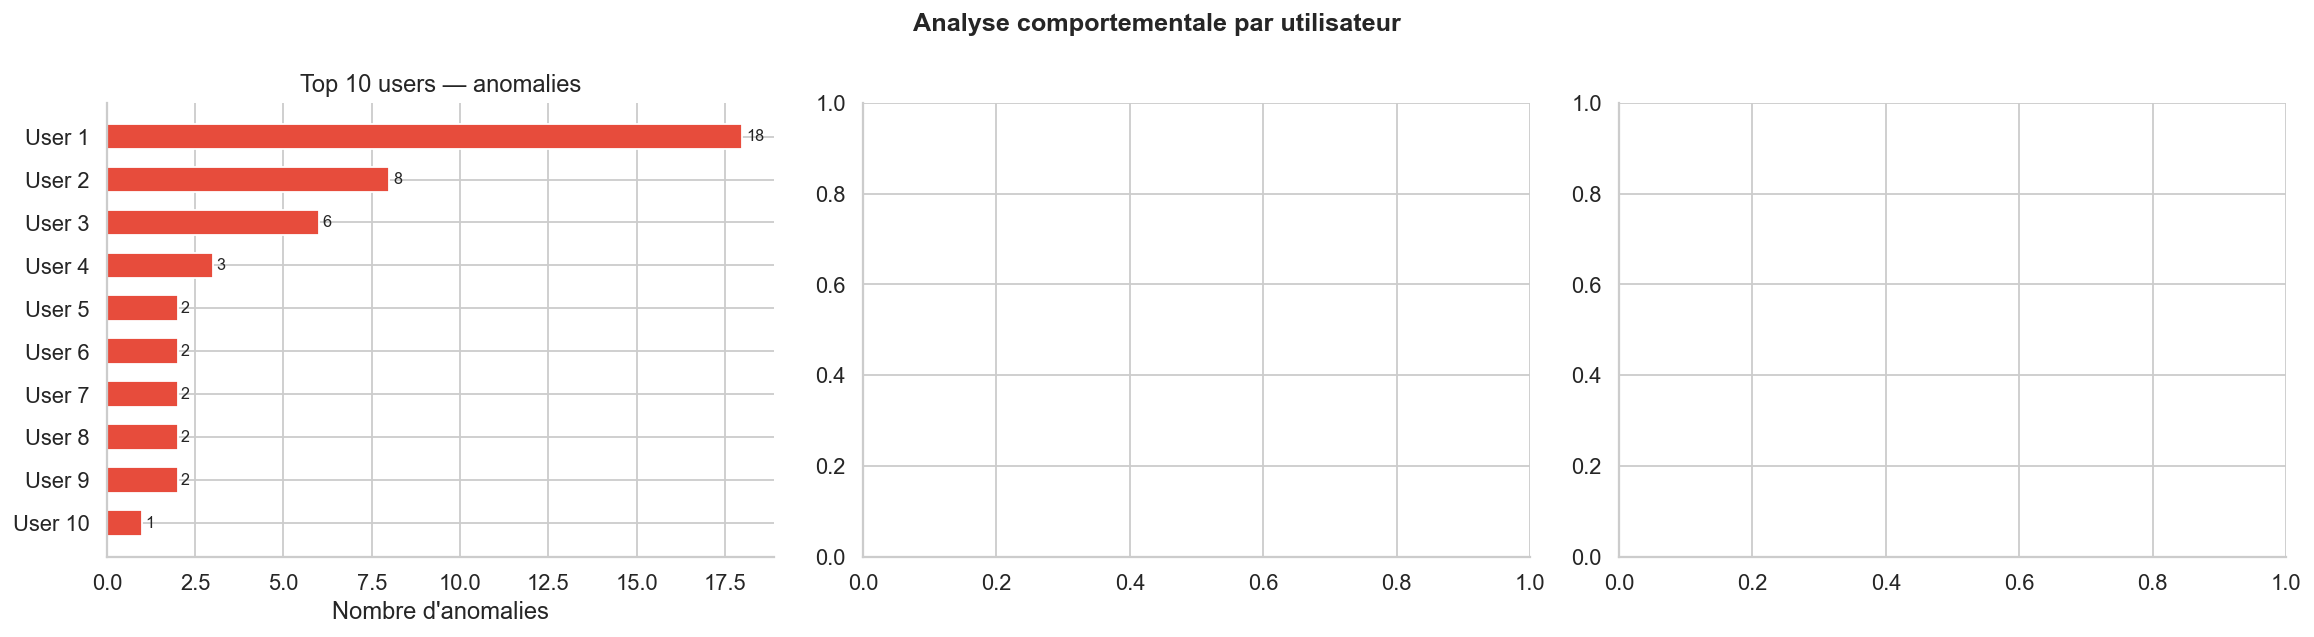

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Analyse comportementale par utilisateur", fontsize=14, fontweight="bold")

# Top users avec le plus d'anomalies
ax = axes[0]
top_users = (df_anomalies.groupby("user_id")["is_anomaly"]
             .count().sort_values(ascending=False).head(10))
top_users.index = [f"User {i+1}" for i in range(len(top_users))]
bars = ax.barh(top_users.index[::-1], top_users.values[::-1],
               color=PALETTE_ACCENT, edgecolor="white", height=0.6)
for bar, val in zip(bars, top_users.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
ax.set_xlabel("Nombre d'anomalies")
ax.set_title("Top 10 users — anomalies")

# Heure habituelle vs heure des anomalies
ax = axes[1]
if "hour_of_day" in df_scored.columns:
    ax.hist(df_normal["hour_of_day"],    bins=24, range=(0,24),
            color=PALETTE_MAIN,   alpha=0.6, density=True, label="Normal")
    ax.hist(df_anomalies["hour_of_day"], bins=24, range=(0,24),
            color=PALETTE_ACCENT, alpha=0.8, density=True, label="Anomalie")
    ax.set_xlabel("Heure de la journée")
    ax.set_ylabel("Densité")
    ax.set_title("Distribution horaire")
    ax.legend()
    ax.set_xticks(range(0, 24, 2))

# Écart par rapport à l'heure habituelle du user
ax = axes[2]
if "hour_deviation_from_user_norm" in df_scored.columns:
    ax.hist(df_normal["hour_deviation_from_user_norm"].clip(0, 5),
            bins=30, color=PALETTE_MAIN,   alpha=0.6, density=True, label="Normal")
    ax.hist(df_anomalies["hour_deviation_from_user_norm"].clip(0, 5),
            bins=15, color=PALETTE_ACCENT, alpha=0.8, density=True, label="Anomalie")
    ax.axvline(2.0, color=PALETTE_WARN, linestyle="--",
               linewidth=1.5, label="Seuil règle (2σ)")
    ax.set_xlabel("Écart vs heure habituelle (σ)")
    ax.set_ylabel("Densité")
    ax.set_title("Déviation horaire personnalisée")
    ax.legend()

plt.tight_layout()
plt.show()

# Analyse des montants

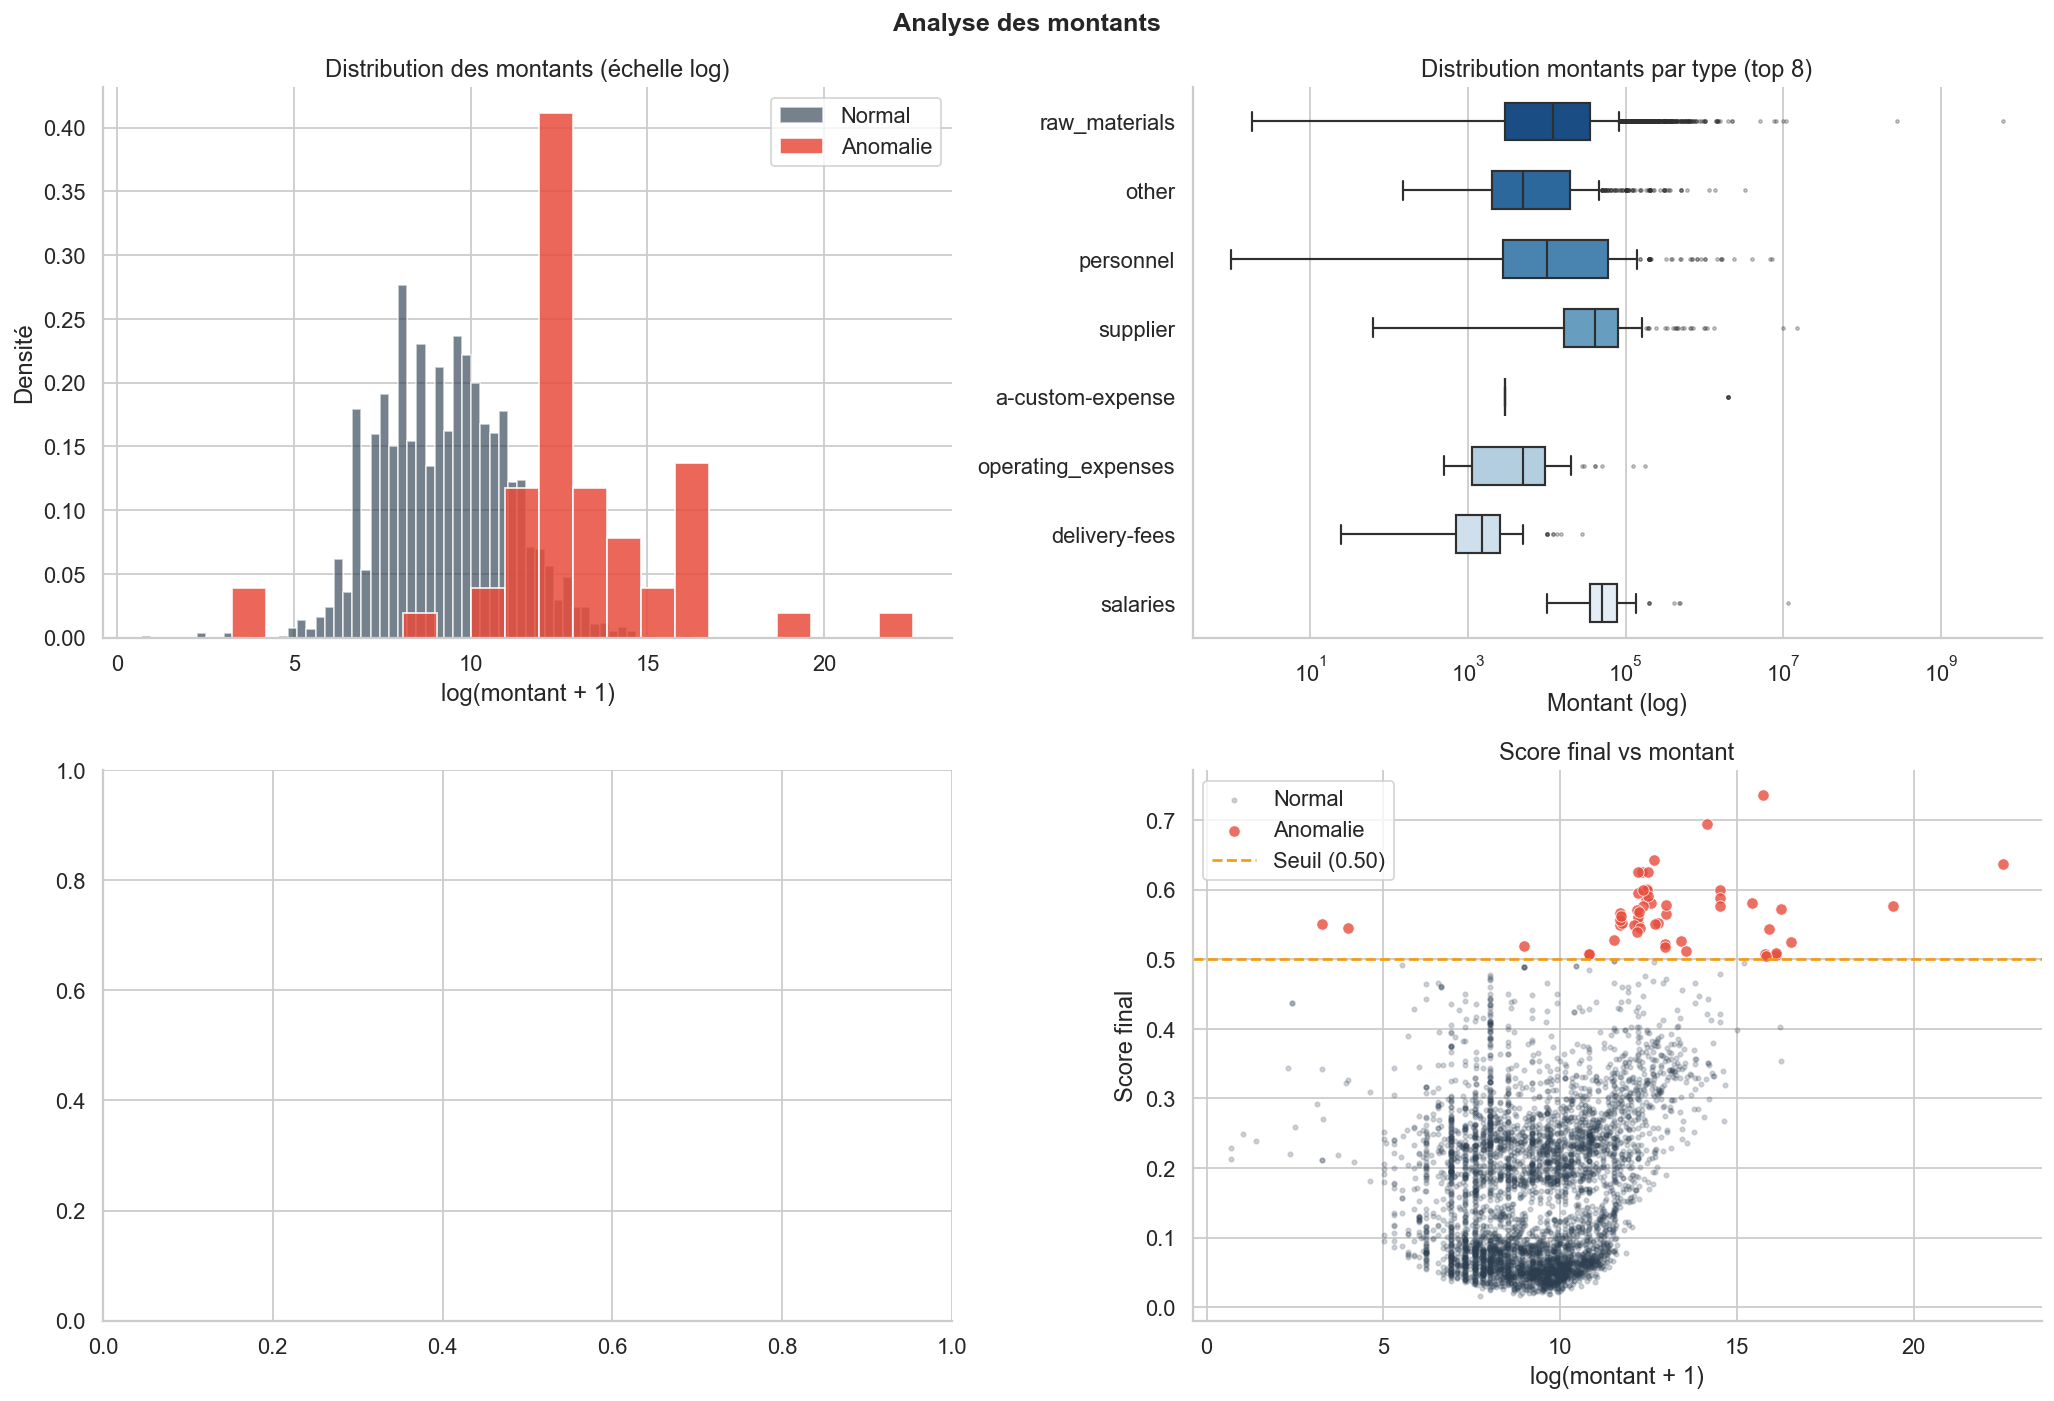

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Analyse des montants", fontsize=14, fontweight="bold")

# Distribution log-montant
ax = axes[0, 0]
ax.hist(np.log1p(df_normal["amount"]),    bins=60, color=PALETTE_MAIN,
        alpha=0.65, density=True, label="Normal")
ax.hist(np.log1p(df_anomalies["amount"]), bins=20, color=PALETTE_ACCENT,
        alpha=0.85, density=True, label="Anomalie")
ax.set_xlabel("log(montant + 1)")
ax.set_ylabel("Densité")
ax.set_title("Distribution des montants (échelle log)")
ax.legend()

# Montants par type de dépense (top 8)
ax = axes[0, 1]
top_types = df_scored["expense_type"].value_counts().head(8).index
df_top = df_scored[df_scored["expense_type"].isin(top_types)]
sns.boxplot(data=df_top, y="expense_type", x="amount",
            order=top_types, palette="Blues_r",
            width=0.55, linewidth=1.2, ax=ax,
            flierprops={"marker": ".", "markersize": 3, "alpha": 0.4})
ax.set_xscale("log")
ax.set_xlabel("Montant (log)")
ax.set_ylabel("")
ax.set_title("Distribution montants par type (top 8)")

# Ratio montant vs médiane user
ax = axes[1, 0]
if "amount_deviation_from_user_median" in df_scored.columns:
    data_clipped = df_scored["amount_deviation_from_user_median"].clip(0, 20)
    ax.hist(data_clipped[df_scored["is_anomaly"]==0],
            bins=50, color=PALETTE_MAIN,   alpha=0.65, density=True, label="Normal")
    ax.hist(data_clipped[df_scored["is_anomaly"]==1],
            bins=20, color=PALETTE_ACCENT, alpha=0.85, density=True, label="Anomalie")
    ax.axvline(5.0, color=PALETTE_WARN, linestyle="--",
               linewidth=1.5, label="Seuil règle (5×)")
    ax.set_xlabel("Montant / médiane habituelle du user")
    ax.set_ylabel("Densité")
    ax.set_title("Écart vs comportement habituel du user")
    ax.legend()

# Score final vs montant (scatter)
ax = axes[1, 1]
ax.scatter(np.log1p(df_normal["amount"]),    df_normal["score_final"],
           color=PALETTE_MAIN,   alpha=0.20, s=6,  label="Normal")
ax.scatter(np.log1p(df_anomalies["amount"]), df_anomalies["score_final"],
           color=PALETTE_ACCENT, alpha=0.80, s=40, label="Anomalie",
           edgecolors="white", linewidth=0.5)
ax.axhline(0.50, color=PALETTE_WARN, linestyle="--",
           linewidth=1.5, label="Seuil (0.50)")
ax.set_xlabel("log(montant + 1)")
ax.set_ylabel("Score final")
ax.set_title("Score final vs montant")
ax.legend()

plt.tight_layout()
plt.show()

# Top 20 anomalies detaillees

In [19]:
top20 = get_top_anomalies(df_scored, n=20)

display_cols = [
    "id", "amount", "expense_type", "source", "created_at",
    "score_final", "score_fraud", "anomaly_if", "anomaly_lof",
    "anomaly_rules", "is_fraud_pattern", "rules_triggered"
]
display_cols = [c for c in display_cols if c in top20.columns]

# Formatage
top20_display = top20[display_cols].copy()
top20_display["amount"]      = top20_display["amount"].apply(lambda x: f"{x:,.0f} XAF")
top20_display["score_final"] = top20_display["score_final"].apply(lambda x: f"{x:.3f}")
top20_display["score_fraud"] = top20_display["score_fraud"].apply(lambda x: f"{x:.3f}")
top20_display["created_at"]  = pd.to_datetime(top20_display["created_at"]).dt.strftime("%Y-%m-%d %H:%M")

# Style
def color_score(val):
    try:
        v = float(val)
        if v >= 0.6:  return "background-color: #FADBD8; font-weight: bold"
        if v >= 0.5:  return "background-color: #FDEBD0"
        return ""
    except:
        return ""

def color_flag(val):
    return "background-color: #FADBD8" if val == 1 else ""

(top20_display.style
    .applymap(color_score, subset=["score_final", "score_fraud"])
    .applymap(color_flag,  subset=["anomaly_if", "anomaly_lof", "anomaly_rules", "is_fraud_pattern"])
    .set_properties(**{"font-size": "11px"})
    .set_caption("🚨 Top 20 transactions les plus suspectes")
)

AttributeError: 'Styler' object has no attribute 'applymap'

# Ajustement du seuil

═══════════════════════════════════════════════════════
  SIMULATION — Impact du seuil sur les résultats
═══════════════════════════════════════════════════════


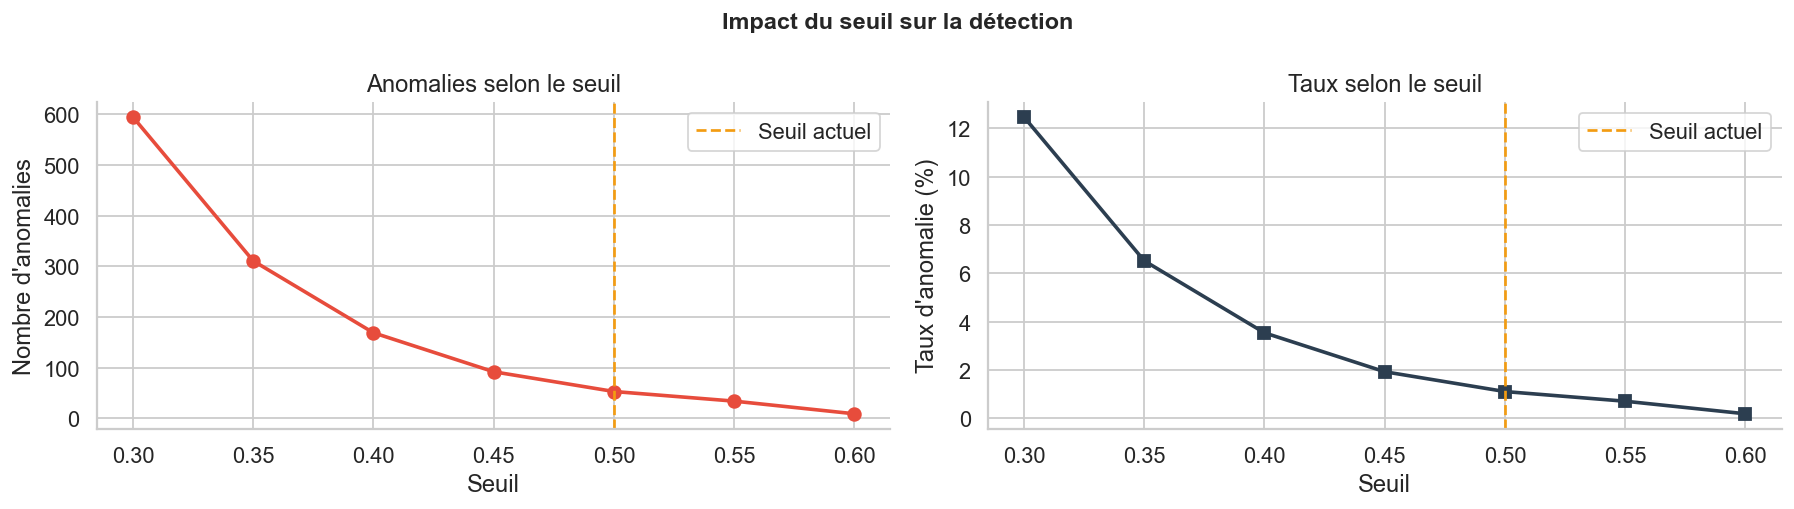

 Seuil  Anomalies  Taux (%) Montant total (XAF)
  0.30        595     12.47       6,562,739,766
  0.35        311      6.52       6,505,421,195
  0.40        169      3.54       6,460,298,040
  0.45         92      1.93       6,432,969,675
  0.50         53      1.11       6,422,463,075
  0.55         34      0.71       6,361,536,194
  0.60          9      0.19       6,061,099,554

→ Seuil actuel : 0.50  (53 anomalies, 1.11%)


In [20]:
print("═" * 55)
print("  SIMULATION — Impact du seuil sur les résultats")
print("═" * 55)

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
rows = []
for t in thresholds:
    n = (df_scored["score_final"] >= t).sum()
    pct = n / len(df_scored) * 100
    amt = df_scored.loc[df_scored["score_final"] >= t, "amount"].sum()
    rows.append({"Seuil": t, "Anomalies": n, "Taux (%)": round(pct, 2),
                 "Montant total (XAF)": f"{amt:,.0f}"})

df_thresholds = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Impact du seuil sur la détection", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(thresholds, df_thresholds["Anomalies"], "o-",
        color=PALETTE_ACCENT, linewidth=2, markersize=7)
ax.axvline(0.50, color=PALETTE_WARN, linestyle="--", linewidth=1.5, label="Seuil actuel")
ax.set_xlabel("Seuil")
ax.set_ylabel("Nombre d'anomalies")
ax.set_title("Anomalies selon le seuil")
ax.legend()

ax = axes[1]
ax.plot(thresholds, df_thresholds["Taux (%)"], "s-",
        color=PALETTE_MAIN, linewidth=2, markersize=7)
ax.axvline(0.50, color=PALETTE_WARN, linestyle="--", linewidth=1.5, label="Seuil actuel")
ax.set_xlabel("Seuil")
ax.set_ylabel("Taux d'anomalie (%)")
ax.set_title("Taux selon le seuil")
ax.legend()

plt.tight_layout()
plt.show()

print(df_thresholds.to_string(index=False))
print(f"\n→ Seuil actuel : 0.50  ({summary['total_anomalies']} anomalies, {summary['anomaly_rate_pct']}%)")